In [1]:
import json
import pandas as pd
from collections import Counter
import shap
import pickle

In [2]:
import os
import sys

project_root = os.path.abspath("..")
sys.path.insert(0, project_root)

In [3]:
from data_gathering.utils.util import clean_text
from classification.utils_finetune import load_dataset, split_dataset

C:\Users\imruh\miniconda3\envs\seafare_nlp\Lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.5.0) or chardet (7.4.3)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(


In [4]:
with open(project_root + "/params.json", 'r') as f:
    PARAMS = json.load(f)

In [5]:
device = "cuda"

In [6]:
model_id = PARAMS["classi_finetune_model"]
dataset = load_dataset()
print(f"Size of dataset: {len(dataset)}")
labels = list(dataset["label"].unique())

label2id, id2label, train_data, test_data, val_data = split_dataset(dataset, labels, train_size=PARAMS["train_split"], val_size=PARAMS["val_split"])

print(f'Train: {Counter(train_data["label"])}')
print(f'Test: {Counter(test_data["label"])}')
print(f'Val: {Counter(val_data["label"])}')

df = pd.read_csv("data/themes_from_thesis.csv", sep="\t")
primary_texts = [clean_text(x) for x in df["EXCERPT"]]

Cleaning text


100%|██████████| 3067/3067 [00:00<00:00, 613707.86it/s]

Size of dataset: 3067
{'HIGH': 0, 'MEDIUM': 1, 'LOW': 2}
{0: 'HIGH', 1: 'MEDIUM', 2: 'LOW'}
Train: Counter({1: 1156, 2: 883, 0: 414})
Test: Counter({1: 145, 2: 110, 0: 52})
Val: Counter({1: 144, 2: 111, 0: 52})


In [7]:
from xai.utils import print_attr, merge_tokens, group_values, get_class_contribs, get_tokenizer # get_model, predict_proba,

In [8]:
from transformers import pipeline

In [9]:
tokenizer = get_tokenizer()

# explainer = shap.Explainer(
#     predict_proba,
#     tokenizer,
#     output_names=["LOW", "MEDIUM", "HIGH"],
#     silent=True
# )

# # takes around an hour
# print("Val data")
sample_texts_val = list(val_data["text"])
# shap_values_val = explainer(sample_texts_val)
# print("Primary texts")
sample_texts_primary = list(primary_texts)
# shap_values_primary = explainer(sample_texts_primary)

# with open(f"shap_values/shap_val.pkl", "wb") as f:
#         pickle.dump(shap_values_val, f)

# with open(f"shap_values/shap_primary.pkl", "wb") as f:
#         pickle.dump(shap_values_primary, f)

In [10]:
with open(f"data/shap_val.pkl", "rb") as f:
        shap_values_val = pickle.load(f)

with open(f"data/shap_primary.pkl", "rb") as f:
        shap_values_primary = pickle.load(f)

shap_val = shap_values_val.values
data_val = [tokenizer.tokenize(x) for x in sample_texts_val]

shap_primary = shap_values_primary.values
data_primary = [tokenizer.tokenize(x) for x in sample_texts_primary]

Token indices sequence length is longer than the specified maximum sequence length for this model (572 > 512). Running this sequence through the model will result in indexing errors


In [13]:
val_contribs, val_contexts, val_idxs = get_class_contribs(data_val, shap_val, group=6)
primary_contribs, primary_contexts, primary_idxs = get_class_contribs(data_primary, shap_primary, group=6)

outputs = [
            [val_contribs, val_contexts, val_idxs, id2label, "positive", 20, "data/top_pos_val_roberta.txt"],
            [val_contribs, val_contexts, val_idxs, id2label, "negative", 20, "data/top_neg_val_roberta.txt"],
            [primary_contribs, primary_contexts, primary_idxs, id2label, "positive", 20, "data/top_pos_primary_roberta.txt"],
            [primary_contribs, primary_contexts, primary_idxs, id2label, "negative", 20, "data/top_neg_primary_roberta.txt"],
            ]


In [73]:
for o in outputs:
    str_ = print_attr(o[0], o[1], o[2], o[3], attr=o[4], top_k=o[5])
    # print(str_)
    with open(o[6], "w", encoding="utf-8") as f:
        f.write(str_)


In [15]:
from xai.utils import plot_token_attributions, merge_roberta_tokens

In [80]:
interesting_val_data = [#32, 131, 136, 172,
                        #123, 104, 32, 172,
                        172, 284, 263, 196] # first two positive, next two negative
label = ["HIGH", "HIGH", "HIGH", "HIGH",
         "MEDIUM", "MEDIUM", "MEDIUM", "MEDIUM",
         "LOW", "LOW", "LOW", "LOW"]

preds = [0,0,0,0] # np.argmax(explainer.model(texts), axis=1)
shap.initjs()
for j, i in zip(interesting_val_data, label):
        print(i)
        i = label2id[i]
        tokens_all = tokenizer.tokenize(sample_texts_val[j])
        values_all = shap_val[j][:,i]
        tokens, scores = merge_roberta_tokens(tokens_all, values_all)
        positive_color = "#ca0020"
        negative_color = "#92c5de"


        shap.plots.text(shap_values_val[j,:,i])
        min_len = min(len(tokens), len(scores))
        tokens = tokens[:min_len]
        scores = scores[:min_len]
        # plot_token_attributions(None, tokens, scores, spacing=0.01, fontsize=16)


HIGH


HIGH


HIGH


HIGH


HIGH


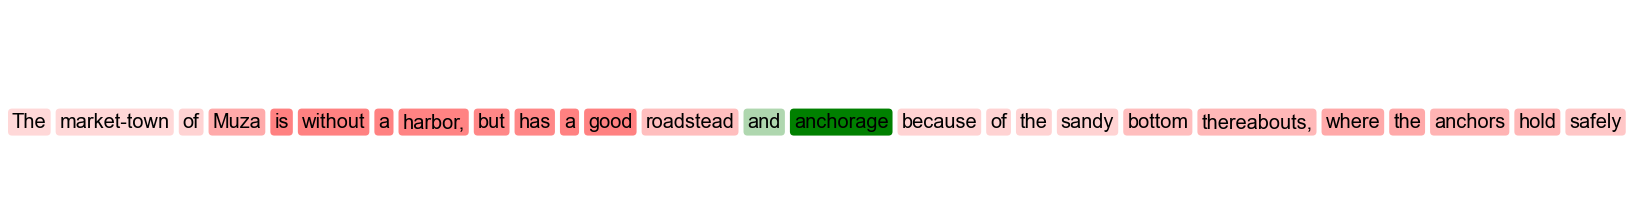

HIGH


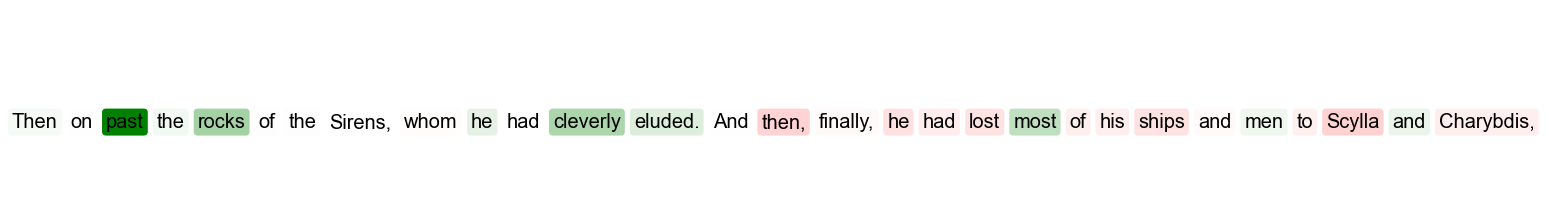

HIGH


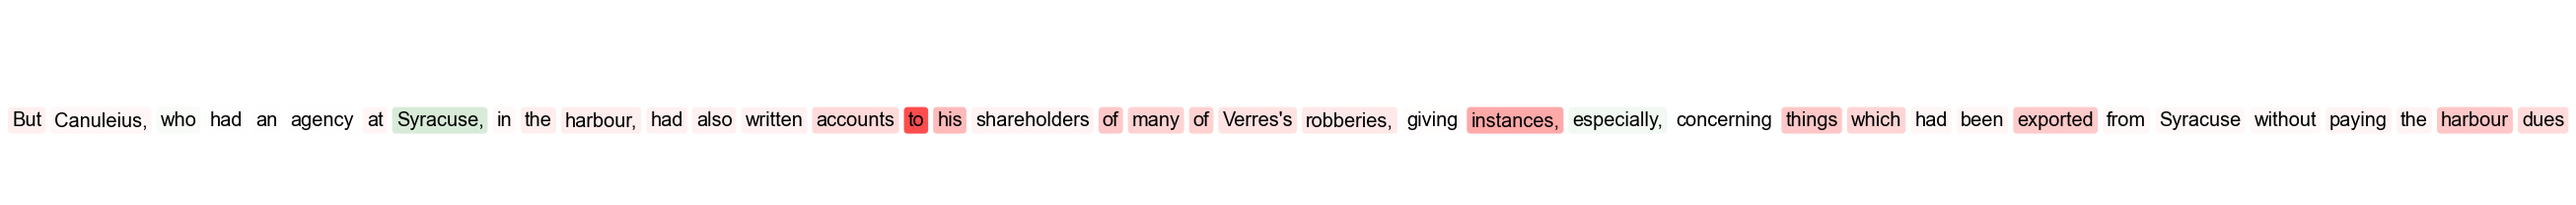

HIGH


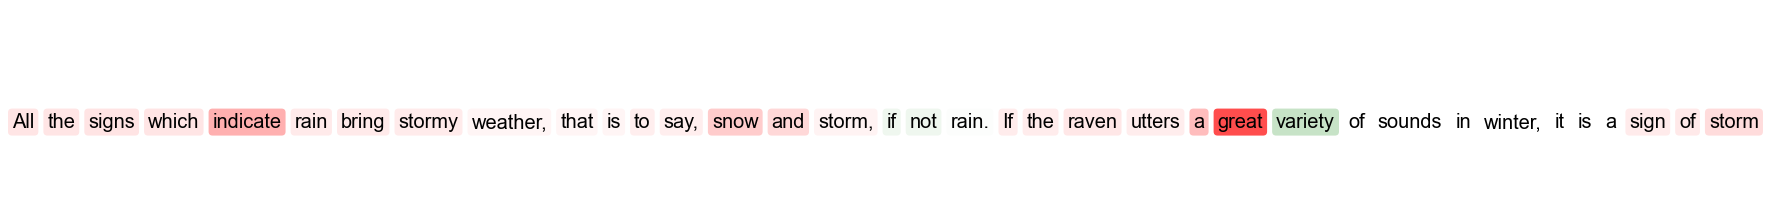

MEDIUM


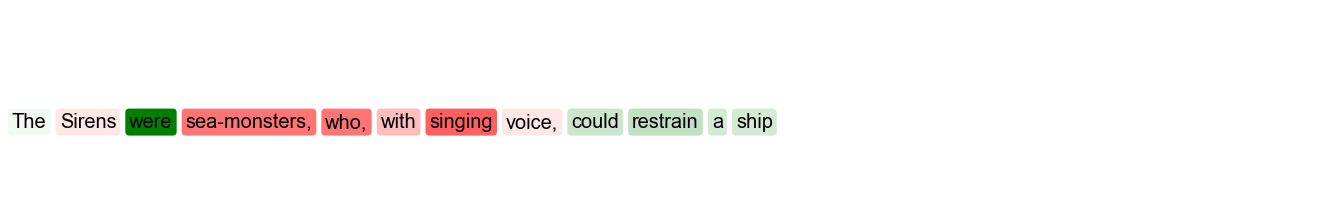

MEDIUM


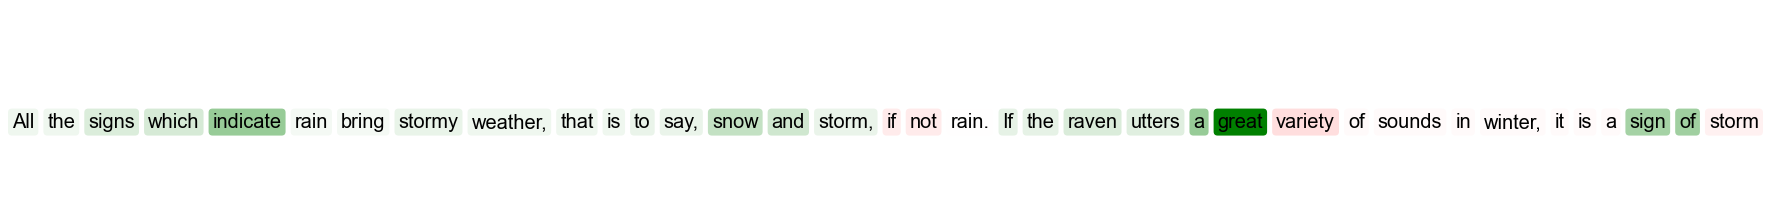

MEDIUM


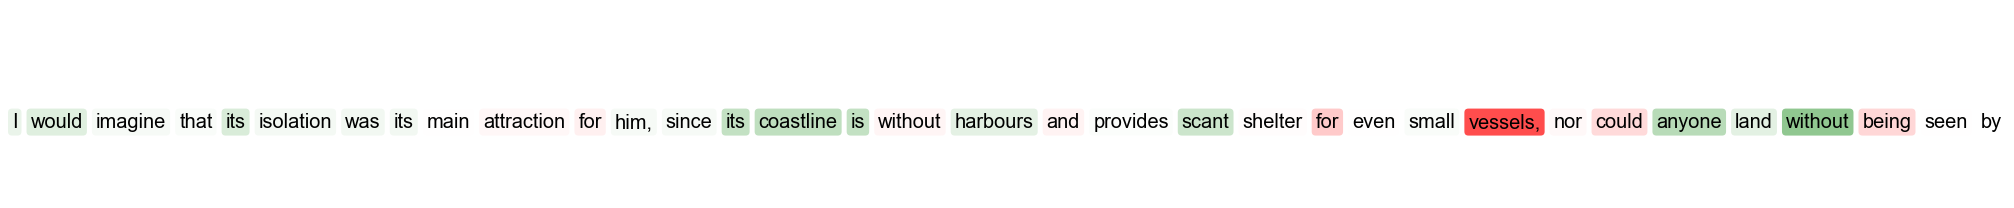

MEDIUM


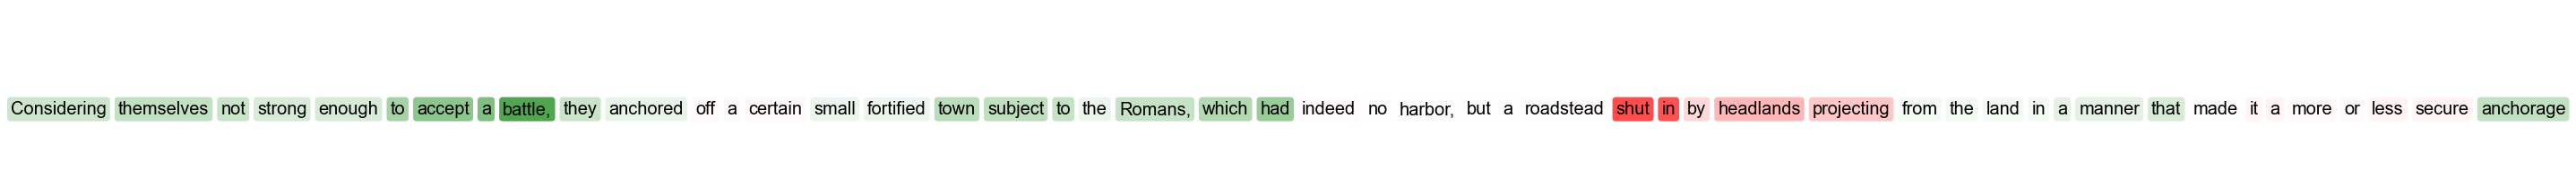

LOW


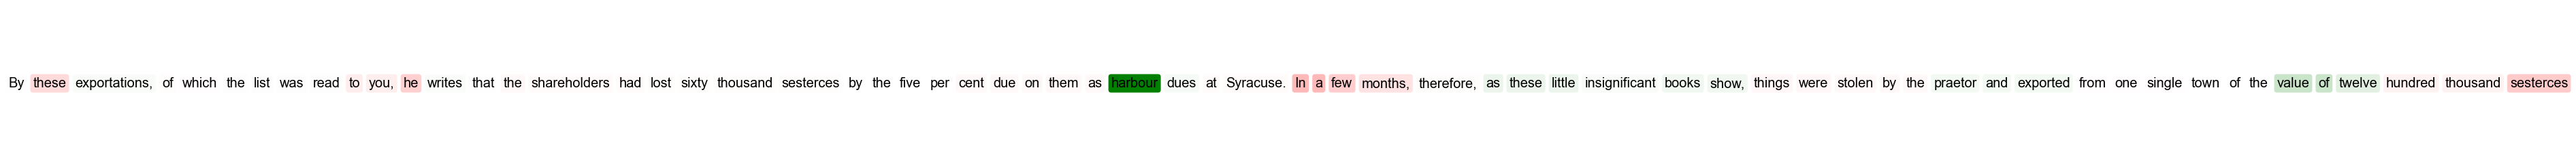

LOW


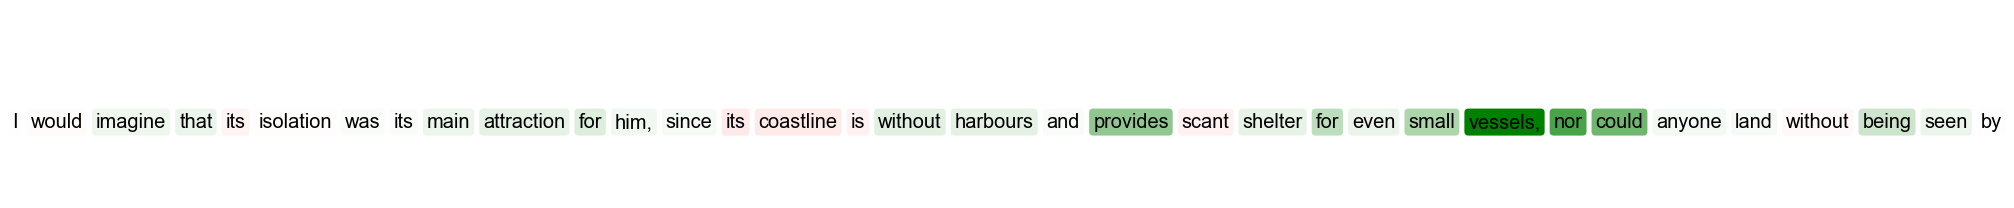

LOW


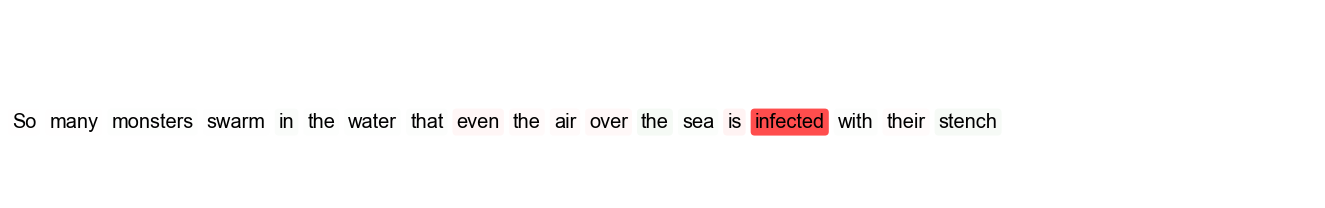

LOW


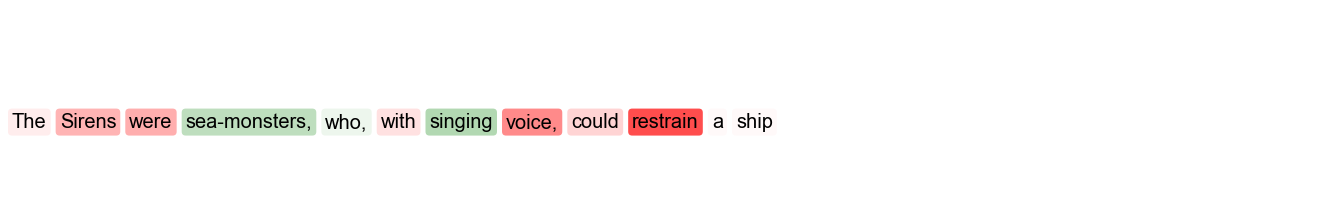

In [75]:
interesting_primary_data = [ 8, 37, 31, 149,
                         100, 149, 141, 111,
                         30, 141, 101, 100

] # first two positive, next two negative
label = ["HIGH", "HIGH", "HIGH", "HIGH",
         "MEDIUM", "MEDIUM", "MEDIUM", "MEDIUM",
         "LOW", "LOW", "LOW", "LOW"]

preds = [0,0,0,0] # np.argmax(explainer.model(texts), axis=1)
shap.initjs()
for j, i in zip(interesting_primary_data, label):
        print(i)
        i = label2id[i]
        tokens_all = tokenizer.tokenize(sample_texts_primary[j])
        values_all = shap_val[j][:,i]
        tokens, scores = merge_roberta_tokens(tokens_all, values_all)
        positive_color = "#ca0020"
        negative_color = "#92c5de"


        shap.plots.text(shap_values_primary[j,:,i])
        min_len = min(len(tokens), len(scores))
        tokens = tokens[:min_len]
        scores = scores[:min_len]
        # plot_token_attributions(None, tokens, scores, spacing=0.01, fontsize=12)
